In [1]:
from microscope_calibration.common.model import Parameters4DSTEM, DescanError, PixelYX, Model4DSTEM, Ray, trace, symbol_maker

from temgym_core.run import run_iter
from temgym_core.components import Component

import jax
import jax.numpy as jnp
import numpy as np
import sympy as sym
from sympy import S
from types import ModuleType

In [2]:
p = Parameters4DSTEM(
    overfocus=0.01,
    scan_pixel_pitch=1e-6,
    scan_center=PixelYX(0.1, 0.2),
    scan_rotation=0.01,
    camera_length=1.0,
    detector_pixel_pitch=50e-6,
    detector_center=PixelYX(0.1, 0.1),
    semiconv=1e-3,  # radian
    flip_factor=1.0,
    descan_error=DescanError(sxo_pxi=1, syo_pyi=-3),
    xp=np
)

In [3]:
def get_equation_sympy(de: DescanError, scan_px):
    tr = trace(
    params = Parameters4DSTEM(
    overfocus=0.,
    scan_pixel_pitch=scan_px,
    scan_center=PixelYX(0., 0.),
    scan_rotation=0.0,
    camera_length=1.0,
    detector_pixel_pitch=50e-6,
    detector_center=PixelYX(0., 0.),
    semiconv=1e-3,  # radian
    flip_factor=1.0,
    descan_error=de,
    xp=np),
    scan_pos=PixelYX(0., 0.),
    source_dy=0.,
    source_dx=0.,
)
    
    return tr['detector'].sampling['detector_px']

In [4]:
#get_equation_sympy(DescanError(pxo_pxi=0.0, pxo_pyi=0.0, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=1, sxo_pyi=0.0, syo_pxi=0.0, syo_pyi=-3, offpxi=0.0, offpyi=0.0, offsxi=0.0, offsyi=0.0), 2.5)

In [5]:
def test(source_dx):
    tr = trace(
        params=p,
        scan_pos=PixelYX(0.1, 0.1),
        source_dy=0.23,
        source_dx=source_dx,
    )
    return tr['detector'].sampling['detector_px'].x

In [6]:
def testjax(source_dx):
    tr = trace(
        params=p.derive(xp=jnp),
        scan_pos=PixelYX(0., 0.),
        source_dy=0.,
        source_dx=source_dx,
    )
    return tr['detector'].sampling['detector_px'].x

In [7]:
#jax.grad(testjax)(0.)

In [8]:
x = sym.symbols('x')
test(np.array((x)))

20200.0*x + 0.0980000999991667

In [9]:
x * 1 == x - x + x
#x = sym.Symbol('x', zero=True)

True

In [10]:
x = sym.Symbol('x')
model = Model4DSTEM.build(params=p, scan_pos=PixelYX(0.01, 0.2))
ray = model.make_source_ray(source_dx=x, source_dy=0.2).ray

res = list(run_iter(ray=ray, components=model.components))

comp, r = res.pop(0)
print(ray.dx)

x


In [11]:
# does not reconize e.g. np.array((x, 1)) as sympy
def is_sympy(x) -> bool:
    return isinstance(x, sym.Expr)

def sympy_equals(a, b) -> bool:
    return sym.simplify(a - b).is_zero is True

In [12]:
def equals(ray1: Ray, ray2: Ray) -> bool:
    for key in ray1.__dict__.keys():
        if (is_sympy(ray1.__dict__[key]) or is_sympy(ray2.__dict__[key])):
            if not sympy_equals(ray1.__dict__[key], ray2.__dict__[key]):
                return False
        else:
            if ray1.__dict__[key] != ray2.__dict__[key]:
                return False
    return True

In [13]:
equals(Ray(x, 0, 0, 0, 0, 0), Ray(np.array((x)), 0, 0, 0, 0, 0)) is True

True

In [14]:
sym.simplify(np.array((x)) - x)

0

In [15]:
sym.simplify(np.array((x,)) - x)

[0]

In [16]:
sym.simplify(np.array((x,)) - x) == sym.Array([0])

True

In [17]:
isinstance(sym.simplify(np.array((x, )) - x), sym.Array)

True

In [18]:
#_protected(...)
#__private(...)

In [19]:
equals(Ray(S(0), x, 0, 0, 0, 0), Ray(0.0, 2*x, 0, 0, 0, 0)) is True

False

In [20]:
is_sympy(list((1,2,x)))

False

In [21]:
is_sympy(Ray(x, 0, 0, 0, 0, 0))

False

In [22]:
l = np.array((x)) # ATTENTION: it works for this
sym.simplify(l-l == 0) is sym.logic.boolalg.BooleanTrue()
#l-l

True

In [23]:
def test_eq(source):
    tr = trace(r)
    return tr['detector'].sampling['detector_px'].x

In [24]:
test(x)

20200.0*x + 0.0980000999991667

In [25]:
x*0.5 +1 == x*2 - 1.5*x + 2 - 1.0

False

In [26]:
x*0.5 + 1 - (x*2 - 1.5*x + 2 - 1.0)==0

True

In [27]:
sym.simplify(x*0.5 +1 - (x*2 - 1.5*x + 2 - 1.0))==0

True

In [28]:
a, b = sym.symbols('a b')
(a+b)**2 - (a**2 +2*a*b + b**2) == 0

False

In [29]:
sym.simplify((a+b)**2 - (a**2 +2*a*b + b**2)) == 0

True

In [30]:
sym.simplify((a+b)**2 - (a**2 +2*a*b + b**2) == 0) is sym.logic.boolalg.BooleanTrue() # comparison !!!ATTENTION it does not work

False

In [31]:
 sym.logic.boolalg.BooleanTrue()

True

In [32]:
0-0.0 == 0

True

In [33]:
a = np.array((23., 42.))

In [34]:
sym.simplify(a - a*1 == 0) is sym.logic.boolalg.BooleanTrue()

False

In [35]:
isinstance(x, sym.Expr) is True # proving if is sympy

True

In [36]:
np.array((x, x)) == x

array([ True,  True])

In [37]:
b = jax.numpy.array((23., 42.))

In [38]:
#bool(sym.simplify(b - b == 0))

In [39]:
x

x

In [40]:
x.__class__.__name__

'Symbol'

In [41]:
(S(0 - 0.0) == 0) is True

False

In [42]:
(0 - 0.0 == 0) is True

True

In [43]:
S(0 - 0.0 == 0) is S.true

True

In [44]:
S(0-0.0) is S.Zero

False

In [45]:
sym.simplify(0-0.0).is_zero is True

True

In [46]:
a, b = sym.symbols('a b')
sym.simplify((a+b)**2 - (a**2 +2*a*b + b**2)).is_zero is True

True

In [47]:
sym.simplify(1*x-1.0*x - 1.0 + 1).is_zero is True

True

In [48]:
sym.simplify(0.0).is_zero is True

True

In [49]:
S(0.0).is_zero

True

In [50]:
S(0).is_zero

True

In [51]:
is_sympy(S(0))

True

In [52]:
sym.Or(is_sympy(np.array((x, 1))), is_sympy(ray.__dict__['x'])) is S.true

False

In [53]:
is_sympy(r.__dict__['x'])

True

In [54]:
r.__dict__['x']

0

In [55]:
(is_sympy(np.array((x, 1))) or is_sympy(ray.__dict__['x'])) is True

False

In [56]:
isinstance(np.array((x, 1)), sym.Expr)

False

In [57]:
type(np.array((x, 1)))

numpy.ndarray

In [58]:
a, b = sym.symbols('a b')
sym.simplify((a+b)**2 - (a**2 +2*a*b + b**2)).is_zero is True

True

In [59]:
l = [x]
l.append(l)
x = sym.Symbol('x')

In [60]:
l

[x, [...]]

In [61]:
from typing import Iterable #Sequence # typing or collections.abc?

In [62]:
def is_sympy_recursive(a, checked=set()):
    if id(a) in checked:
        return False
    checked.add(id(a))
    if isinstance(a, Iterable):
        return any(is_sympy_recursive(x, checked=checked) for x in a)
    else:
        return isinstance(a, sym.Expr)

In [63]:
is_sympy_recursive(l, checked=set())

True

In [64]:
type(sym.simplify(0-0.0)) == 0.0

False

In [65]:
is_sympy(S(6))

True

In [66]:
f = sym.Function('f')(x)
is_sympy(f.subs(x, 1))

True

In [67]:
A = sym.Matrix([[1,2],[2,3]])

In [68]:
is_sympy_recursive(A)

False

In [69]:
def is_sympy_basic(x) -> bool:
    return isinstance(x, sym.Basic)

In [70]:
is_sympy_basic(sym.sympify(sym.Matrix([1])))

True

In [71]:
sym.sympify([1,2])

[1, 2]

In [72]:
is_sympy(x> 0)

False

In [73]:
is_sympy_basic(S(A))

True

In [74]:
Ar = sym.Array([1,2])
B = sym.Matrix([[1,2],[3,4]])
isinstance(Ar, sym.NDimArray)
sym.simplify(A-B)
isinstance(x, (sym.Basic, sym.MatrixBase, sym.NDimArray))

True

In [75]:
((a+b)**2).equals(a**2 +2*a*b+b**2)

True

In [76]:
def equals_with_sympy_equals(ray1: Ray, ray2: Ray) -> bool:
    for key in ray1.__dict__.keys():
        if (is_sympy(ray1.__dict__[key]) or is_sympy(ray2.__dict__[key])):
            if not ray1.__dict__[key].equals(ray2.__dict__[key]):
                return False
        else:
            if ray1.__dict__[key] != ray2.__dict__[key]:
                return False
    return True

In [77]:
equals_with_sympy_equals(Ray((a+b)**2, 0, 0, 0, 0, 0), Ray(a**2 + 2*a*b + b**2, 0, 0, 0, 0, 0))

True

In [78]:
#equals_with_sympy_equals(Ray(0.0,0,0,0,0,0), Ray(S(0),0,0,0,0,0))

In [79]:
#equality(Ray(0.0,0,0,0,0,0), Ray(S(0),0,0,0,0,0))

In [80]:
S(0).equals(0.0)

True

In [81]:
sym.Number(0.0).equals(S(0))

True

In [82]:
sym.simplify(0.0).equals(S(0))

True

In [83]:
sym.Expr(0.0)

Expr(0.0)

In [84]:
from microscope_calibration.common.model import rotate

In [85]:
import numpy.typing as npt
import jax.numpy as jnp

In [86]:
isinstance(jnp.array((1, 2, 3)), npt.ArrayLike)

True

In [87]:
jnp.ndarray()

In [88]:
type(jnp.ndarray())

jax.Array

In [89]:
def npt_test(a: npt.ArrayLike):
    return 'it works'

In [90]:
f = jnp.ndarray()
npt_test(f)

'it works'

In [91]:
jnp.ndarray()

In [92]:
jnp.array((1, 2, 3))

Array([1, 2, 3], dtype=int64)

In [93]:
isinstance(23, (float, str))

False

In [94]:
from typing import Union, Optional

Optional[Union[int, float]]

typing.Union[int, float, NoneType]

In [95]:
int | float | None

int | float | None

In [96]:
from sympy.abc import a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w
par = Parameters4DSTEM(
    overfocus=0.01*a,
    scan_pixel_pitch=1e-6*b,
    scan_center=PixelYX(0.1*c, 0.2*d),
    scan_rotation=0.01*e,
    camera_length=1.0*f,
    detector_pixel_pitch=50e-6*g,
    detector_center=PixelYX(0.1*h, 0.1*i),
    semiconv=1e-3*j,  # radian
    flip_factor=1.0*k,
    descan_error=DescanError(pxo_pxi=l, pxo_pyi=m, pyo_pxi=n, pyo_pyi=o, sxo_pxi=p, sxo_pyi=q, syo_pxi=r, syo_pyi=s, offpxi=t, offpyi=u, offsxi=v, offsyi=w),
)

In [97]:
par.descan_error

DescanError(pxo_pxi=l, pxo_pyi=m, pyo_pxi=n, pyo_pyi=o, sxo_pxi=p, sxo_pyi=q, syo_pxi=r, syo_pyi=s, offpxi=t, offpyi=u, offsxi=v, offsyi=w)

In [98]:
def test_adjust():
    answer = Parameters4DSTEM.adjust_scan_pixel_pitch(
        par,
        scan_pixel_pitch = 2.5
    )
    return answer.descan_error

In [99]:
test_adjust()

DescanError(pxo_pxi=4.0e-7*b*l, pxo_pyi=4.0e-7*b*m, pyo_pxi=4.0e-7*b*n, pyo_pyi=4.0e-7*b*o, sxo_pxi=4.0e-7*b*p, sxo_pyi=4.0e-7*b*q, syo_pxi=4.0e-7*b*r, syo_pyi=4.0e-7*b*s, offpxi=t, offpyi=u, offsxi=v, offsyi=w)

In [100]:
par.descan_error.__getitem__(0)

l

In [101]:
for item in par.descan_error._fields:
    print(item)

pxo_pxi
pxo_pyi
pyo_pxi
pyo_pyi
sxo_pxi
sxo_pyi
syo_pxi
syo_pyi
offpxi
offpyi
offsxi
offsyi


In [102]:
test_adjust().pxo_pxi / par.descan_error.pxo_pxi

4.0e-7*b

In [103]:
add, div = sym.symbols('add div')
sym.solve([(test_adjust().pxo_pxi - add) * div / par.scan_pixel_pitch - par.descan_error.pxo_pxi, (test_adjust().pxo_pyi - add) * div / par.scan_pixel_pitch - par.descan_error.pxo_pyi], [add, div], dict=True)

[{add: 0.0, div: 2.50000000000000}]

In [104]:
res = sym.symbols('res')
def adjust_new(param, scan_pixel_pitch):
    return sym.solve(param.descan_error.pxo_pxi * param.scan_pixel_pitch / scan_pixel_pitch - res, res)

In [105]:
adjust_new(par, scan_pixel_pitch=2.5)

[4.0e-7*b*l]

In [106]:
res = sym.symbols('res')
def adjust_multiple(param, scan_pixel_pitch):
    result_list = []
    for key in param.descan_error._asdict().keys():
        result_list.append(sym.solve(param.descan_error._asdict()[key] * param.scan_pixel_pitch / scan_pixel_pitch - res, res))
    return result_list

In [107]:
adjust_multiple(par, 2.5)

[[4.0e-7*b*l],
 [4.0e-7*b*m],
 [4.0e-7*b*n],
 [4.0e-7*b*o],
 [4.0e-7*b*p],
 [4.0e-7*b*q],
 [4.0e-7*b*r],
 [4.0e-7*b*s],
 [4.0e-7*b*t],
 [4.0e-7*b*u],
 [4.0e-7*b*v],
 [4.0e-7*b*w]]

In [108]:
par.descan_error.__getattribute__('pxo_pxi')

l

In [109]:
par.descan_error._asdict().keys()

dict_keys(['pxo_pxi', 'pxo_pyi', 'pyo_pxi', 'pyo_pyi', 'sxo_pxi', 'sxo_pyi', 'syo_pxi', 'syo_pyi', 'offpxi', 'offpyi', 'offsxi', 'offsyi'])

In [110]:
#def create_scan_pixel_pitch_fn(model_cls=Model4DSTEM):
    # just for documenting the signature
    #def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
    #    ...
    #attr_updated = sym.symbols('attr_updated')
    #def attr_update(attr, scan_pixel_pitch_old, scan_pixel_pitch_new):
    #    return sym.solve(attr*scan_pixel_pitch_old/scan_pixel_pitch_new - attr_updated, attr_updated)
    #def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
    #    return Model4DSTEM(res...)
    #return update_scan_pixel_pitch

In [111]:
attr_updated = sym.symbols('attr_updated')
def attr_update(attr, scan_pixel_pitch_old, scan_pixel_pitch_new):
    return sym.solve(attr*scan_pixel_pitch_old/scan_pixel_pitch_new - attr_updated, attr_updated)

In [112]:
attr_update(par.descan_error.pxo_pxi, par.scan_pixel_pitch, 2.5)

[4.0e-7*b*l]

In [113]:
values = np.random.random(6)
# "*" means to apply sequence as positional arguments
ray = Ray(*(float(v) for v in values))
def test_equals(ray1, ray2, expected):
    # Note that __dict__.keys() will not work currently because _one is missing in derive.
    # To be debated if this should be added
    for attr in Ray.__match_args__[:6]:
        # "**" means apply dict as keyword arguments
        left = ray.derive(**{attr: x})
        right = ray.derive(**{attr: x})
        res = equals(left, right)
        # because commutative
        res2 = equals(right, left)
        return (res is expected, res2 is expected)
        #assert res is expected
        #assert res2 is expected

In [114]:
values = np.random.random(6)
# "*" means to apply sequence as positional arguments
ray = Ray(*(float(v) for v in values))
ray

Ray(x=0.43555645101056906, y=0.3077360496175696, dx=0.6626234433877776, dy=0.2728922500678306, z=0.8102081352228446, pathlength=0.9551051767587974, _one=1.0)

In [115]:
Ray.__match_args__[:6]


('x', 'y', 'dx', 'dy', 'z', 'pathlength')

In [116]:
ray_1 = Ray(*(float(v) for v in values))
ray_2 = Ray(*(float(v) for v in values))

test_equals(ray_1, ray_2, True)

(True, True)

In [117]:
ray.__dict__

{'x': 0.43555645101056906,
 'y': 0.3077360496175696,
 'dx': 0.6626234433877776,
 'dy': 0.2728922500678306,
 'z': 0.8102081352228446,
 'pathlength': 0.9551051767587974,
 '_one': 1.0}

In [118]:
def equals(ray1: Ray, ray2: Ray) -> bool:
    '''
    Compare two rays that may contain sympy expressions to check if they are equal. 
    The comparison is done by the ray components. 
    Use normal comparison except for sympy instances (use is_sympy() to prove that), 
    where apply sympy_equals() function. 

    If comparing x = sym.Symbol('x') and a number, returns False, not None.
    However, x = sym.Symbol('x', zero=True) and 0 works (returns True).
    '''
    for key in ray1.__dict__.keys():
        if (is_sympy(ray1.__dict__[key]) or is_sympy(ray2.__dict__[key])):
            if not sympy_equals(ray1.__dict__[key], ray2.__dict__[key]):
                return False
        else:
            if ray1.__dict__[key] != ray2.__dict__[key]:
                return False
    return True

In [119]:
def equals(ray1: Ray, ray2: Ray) -> bool:
    for attr in ray1.__match_args__[:6]:
        if (is_sympy(ray1.__getattribute__(attr)) or is_sympy(ray2.__getattribute__(attr))):
            if not simpy_equals(ray1.__getattribute__(attr), ray2.__getattribute__(attr)):
                return False
        else:
            if ray1.__getattribute__(attr) != ray2.__getattribute__(attr):
                return False
        return True

In [120]:
equals(ray_1, ray_2)

True

In [121]:
ray.derive()

Ray(x=0.43555645101056906, y=0.3077360496175696, dx=0.6626234433877776, dy=0.2728922500678306, z=0.8102081352228446, pathlength=0.9551051767587974, _one=1.0)

In [122]:
sympy_equals(x, 0)

False

In [123]:
x = sym.Symbol('x', zero=False)


In [124]:
sym.simplify(x-0).is_zero is False

True

In [125]:
x = sym.Symbol('x')
y = x +1
x = 0
y

x + 1

In [126]:
y.equals(1)

False

In [127]:
sym.simplify(x-5).is_zero is True

False

In [128]:
expr = x + 1

In [129]:
sym.simplify(expr-6).is_zero is True

False

In [130]:
class f(sym.Function):
    @classmethod
    def eval(cls, x, y=1, *args):
        return None

In [131]:
f(2, 3).args

(2, 3)

In [132]:
res = sym.Symbol('res')
class solve(sym.Function):
    def attr_update_cls(self):
        a, b, c = self.args
        return sym.solve(a*b/c-res, res)

In [133]:
solve(1, 2, 3).attr_update_cls()

[2/3]

In [134]:
class versin(sym.Function):
    def _eval_is_nonnegative(self):
        # versin(x) is nonnegative if x is real
        x = self.args[0]
        if x.is_real is True:
            return True

In [135]:
versin(1).is_nonnegative

True

In [136]:
def create_scan_pixel_pitch_fn(model_cls=Model4DSTEM):
    
    # just for documenting the signature
    #def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
    #    ...
    
    attr_updated = sym.symbols('attr_updated')
    def attr_update(attr, scan_pixel_pitch_old, scan_pixel_pitch_new):
        return sym.solve(attr*scan_pixel_pitch_old/scan_pixel_pitch_new - attr_updated, attr_updated)
        
    #def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
    #   return Model4DSTEM(res...)
        
    return update_scan_pixel_pitch

In [137]:
def create_scan_pixel_pitch_fn(model_cls=Model4DSTEM):
    
    # just for documenting the signature
    #def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
    #    ...
    
    res = sym.Symbol('res')
    class solve(sym.Function):
        def attr_update(self):
            a, b, c = self.args
            return sym.solve(a*b/c-res, res)
        
    def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
        #attrs = model.params.descan_error._asdict()
        #for attr in attrs.keys():
        #    if attr[0] != 'o':
        #        attr_updated = solve(attr, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update()
        #        attrs[attr] = attr_updated
        parameters = Parameters4DSTEM(overfocus=model.params.overfocus,
            scan_pixel_pitch=model.params.scan_pixel_pitch,
            scan_center=model.params.scan_center,
            scan_rotation=model.params.scan_rotation,
            camera_length=model.params.camera_length,
            detector_pixel_pitch=model.params.detector_pixel_pitch,
            detector_center=model.params.detector_center,
            semiconv=model.params.semiconv,  # radian
            flip_factor=model.params.flip_factor,
            descan_error=DescanError(
                pxo_pxi=solve(model.params.descan_error.pxo_pxi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(), # attrs[pxo_pxi]
                pxo_pyi=solve(model.params.descan_error.pxo_pyi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                pyo_pxi=solve(model.params.descan_error.pyo_pxi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                pyo_pyi=solve(model.params.descan_error.pyo_pyi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                sxo_pxi=solve(model.params.descan_error.sxo_pxi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                sxo_pyi=solve(model.params.descan_error.sxo_pyi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                syo_pxi=solve(model.params.descan_error.syo_pxi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                syo_pyi=solve(model.params.descan_error.syo_pyi, model.params.scan_pixel_pitch, scan_pixel_pitch).attr_update(),
                offpxi=model.params.descan_error.offpxi,
                offpyi=model.params.descan_error.offpyi,
                offsxi=model.params.descan_error.offsxi,
                offsyi=model.params.descan_error.offsyi,
            ),
            xp=model.params.xp)
        return Model4DSTEM.build(params=parameters, scan_pos=model.scan_pos)
        
    return update_scan_pixel_pitch

In [138]:
#create_scan_pixel_pitch_fn()(mod,2)

In [139]:
def create_scan_pixel_pitch_fn(model_cls=Model4DSTEM):
    
    def update_scan_pixel_pitch(model: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
        return Model4DSTEM.build(params=parameters, scan_pos=model.scan_pos)
    return update_scan_pixel_pitch


def adjust_scan_pixel_pitch(params, scan_pixel_pitch: float) -> "Parameters4DSTEM":
        """
        Adjust the scan pixel pitch while keeping the effective descan error
        compensation the same.

        This allows first compensating descan error and then adjusting other parameters.
        """
        self = params
        de = self.descan_error
        ratio = self.scan_pixel_pitch / scan_pixel_pitch

        new_de = DescanError(
            pxo_pyi=de.pxo_pyi * ratio,
            pyo_pyi=de.pyo_pyi * ratio,
            pxo_pxi=de.pxo_pxi * ratio,
            pyo_pxi=de.pyo_pxi * ratio,
            sxo_pyi=de.sxo_pyi * ratio,
            syo_pyi=de.syo_pyi * ratio,
            sxo_pxi=de.sxo_pxi * ratio,
            syo_pxi=de.syo_pxi * ratio,
            offpxi=de.offpxi,
            offpyi=de.offpyi,
            offsxi=de.offsxi,
            offsyi=de.offsyi,
        )
        return self.derive(
            scan_pixel_pitch=scan_pixel_pitch,
            descan_error=new_de,
        )

In [140]:
from sympy.abc import a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z
s1, s2, v1, v2 = sym.symbols('s1 s2 v1 v2')
a, n  = sym.symbols(r'overfocus_{scan_1} \hat{n}')
def get_equation_sympy(de: DescanError, scan_px):
    par = Parameters4DSTEM(
    overfocus=a,
    scan_pixel_pitch=scan_px,
    scan_center=PixelYX(b, c),
    scan_rotation=d,
    camera_length=e,
    detector_pixel_pitch=f,
    detector_center=PixelYX(g, h),
    semiconv=i,  # radian
    flip_factor=j,
    descan_error=de,
    xp=np)
    
    tr1 = trace(
    params = par,
    scan_pos=PixelYX(k, l),
    source_dy=m,
    source_dx=n,
    )
    p_adjusted = adjust_scan_pixel_pitch(par, s2)

    tr2 = trace(
    params = p_adjusted,
    scan_pos=PixelYX(k, l),
    source_dy=m,
    source_dx=n,
    )
    

    equation_y = sym.Eq(tr1['scanner'].component.scan_pos_y / tr2['scanner'].component.scan_pos_y, tr1['detector'].sampling['detector_px'].y / v1)  # v1 = tr2['detector'].sampling['detector_px'].y
    equation_x = sym.Eq(tr1['scanner'].component.scan_pos_x / tr2['scanner'].component.scan_pos_x, tr1['detector'].sampling['detector_px'].x / v2)  # v2 = tr2['detector'].sampling['detector_px'].x
    solution = sym.solve([equation_y, equation_x], x, y)
    
    #return res.descan_error == tr['descanner'].component.descan_error, res.detector_pixel_pitch == tr['detector'].sampling['detector_px']
    return solution

In [141]:
sym.init_printing(use_latex=True)
get_equation_sympy(DescanError(pxo_pxi=p, pxo_pyi=q, pyo_pxi=r, pyo_pyi=s, sxo_pxi=t, sxo_pyi=u, syo_pxi=v, syo_pyi=w, offpxi=x, offpyi=y, offsxi=z, offsyi=o), s1)

In [142]:
def adjust_pixel_pitch_sympy(model_cls=Model4DSTEM) -> Model4DSTEM:
    """
    Adjust the scan pixel pitch while keeping the effective descan error
    compensation the same.

    This allows first compensating descan error and then adjusting other parameters.
    
    This function first finds a general symbolic expression for each component of the
    new descan error given old parameteres as symbols, then converts the sympy
    expressions for each component into a function that allows fast numeric evaluation.
    After that the new model is constructed.

    Use trace() to calculate detector_px() for the old and for the new parameters.
    Then set the results equal to each other and solve the equation with respect
    to the new descan error. For this purpose construct two expressions - for y and x
    coordiates respectively - and apply sympy.solve().
    Note that the equations should hold for every value of the scan position (in particular,
    scan_pos_y scan_pos_x), and also for every value of the camera length. To implement that,
    expand the expressions, then rearange them to be polynomials in the variables scan_pos_y,
    scan_pos_x and camera_length, which automatically means collecting the coefficients
    of each variable through the usage of sympy.Poly(). Finally, set the collected
    coefficients of the polynomials to zero, which mathematically implies the desired
    property: a polynomial is zero for all the values of its variables if and only if
    all its coefficients equal to zero.
    In such a way one receives equations for each of the collected coefficients, which
    suffices to make the system solvable for all the 12 components of descan error as
    variables.

    The received expressions for each component of the new DescanError fully coincide
    with the ones calculated by hand earlier.

    apply_function() cconstructs a function using sympy.lambdify() that allows inserting
    real values to each expression of the general solution and after that evaluating them
    numerically. The lambdify() method can be supplemented with the specific
    numerical backend by inserting e.g. "numpy", "cupy" or "jax" to the optional
    argument "modules=" of sympy.lambdify().
    """
    (overfocus, scan_center_y,
     scan_center_x, scan_rotation,
     camera_length, detector_pitch,
     detector_center_y, detector_center_x,
     semiconv, flip_factor) = sym.symbols(r'p_overfocus p_{scancenter_y} '
                                           'p_{scancenter_x} p_scanrot '
                                           'p_camera p_detectorpitch '
                                           'p_{detectorcenter_y} p_{detectorcenter_x} '
                                           'p_semiconv p_flip', nonzero=True)


    (pxo_pxi_old, pxo_pyi_old,
     pyo_pxi_old, pyo_pyi_old,
     sxo_pxi_old, sxo_pyi_old,
     syo_pxi_old, syo_pyi_old,
     offpxi_old, offpyi_old,
     offsxi_old, offsyi_old) = sym.symbols(r'pxopxi_old pxopyi_old '
                                            'pyopxi_old pyopyi_old '
                                            'sxopxi_old sxopyi_old '
                                            'syopxi_old syopyi_old '
                                            'offpxi_old offpyi_old '
                                            'offsxi_old offsyi_old')
    (pxo_pxi_new, pxo_pyi_new,
     pyo_pxi_new, pyo_pyi_new,
     sxo_pxi_new, sxo_pyi_new,
     syo_pxi_new, syo_pyi_new,
     offpxi_new, offpyi_new,
     offsxi_new, offsyi_new) = sym.symbols(r'pxopxi_new pxopyi_new '
                                            'pyopxi_new pyopyi_new '
                                            'sxopxi_new sxopyi_new '
                                            'syopxi_new syopyi_new '
                                            'offpxi_new offpyi_new '
                                            'offsxi_new offsyi_new')
    
    descan_error_old = DescanError(
        pxo_pxi=pxo_pxi_old, pxo_pyi=pxo_pyi_old,
        pyo_pxi=pyo_pxi_old, pyo_pyi=pyo_pyi_old,
        sxo_pxi=sxo_pxi_old, sxo_pyi=sxo_pyi_old,
        syo_pxi=syo_pxi_old, syo_pyi=syo_pyi_old,
        offpxi=offpxi_old, offpyi=offpyi_old,
        offsxi=offsxi_old, offsyi=offsyi_old)
    
    descan_error_new = DescanError(
        pxo_pxi=pxo_pxi_new, pxo_pyi=pxo_pyi_new,
        pyo_pxi=pyo_pxi_new, pyo_pyi=pyo_pyi_new,
        sxo_pxi=sxo_pxi_new, sxo_pyi=sxo_pyi_new,
        syo_pxi=syo_pxi_new, syo_pyi=syo_pyi_new,
        offpxi=offpxi_new, offpyi=offpyi_new,
        offsxi=offsxi_new, offsyi=offsyi_new
    )
    
    pitch_old, pitch_new = sym.symbols(r'pitch_old pitch_new', nonzero=True)
    
    params_old = Parameters4DSTEM(
        overfocus=overfocus,
        scan_pixel_pitch=pitch_old,
        scan_center=PixelYX(scan_center_y, scan_center_x),
        scan_rotation=scan_rotation,
        camera_length=camera_length,
        detector_pixel_pitch=detector_pitch,
        detector_center=PixelYX(detector_center_y, detector_center_x),
        semiconv=semiconv,  # radian
        flip_factor=flip_factor,
        descan_error=descan_error_old,
        xp=np
    )

    params_new = Parameters4DSTEM(
        overfocus=overfocus,
        scan_pixel_pitch=pitch_new,
        scan_center=PixelYX(scan_center_y, scan_center_x),
        scan_rotation=scan_rotation,
        camera_length=camera_length,
        detector_pixel_pitch=detector_pitch,
        detector_center=PixelYX(detector_center_y, detector_center_x),
        semiconv=semiconv,  # radian
        flip_factor=flip_factor,
        descan_error=descan_error_new,
        xp=np
    )
    
    def detector_px(m: Model4DSTEM):
        ray = m.make_source_ray(
            source_dy=0.,
            source_dx=0.,
        ).ray
        data = m.trace(ray)
        return data['detector'].sampling['detector_px']

    scan_pos_y, scan_pos_x = sym.symbols(r'scan_{pos_y} scan_{pos_x}')
    scan_pos = PixelYX(scan_pos_y, scan_pos_x)

    model_old = Model4DSTEM.build(params=params_old, scan_pos=scan_pos)
    model_new = Model4DSTEM.build(params=params_new, scan_pos=scan_pos)
    
    det_px_old = detector_px(model_old)
    det_px_new = detector_px(model_new)
    
    expanded_expr_y = sym.expand(det_px_old.y - det_px_new.y)
    expanded_expr_x = sym.expand(det_px_old.x - det_px_new.x)

    collected_y = sym.Poly(expanded_expr_y, scan_pos_y, scan_pos_x, camera_length)
    collected_x = sym.Poly(expanded_expr_x, scan_pos_y, scan_pos_x, camera_length)
    
    coeff = collected_y.coeffs() + collected_x.coeffs()
    
    solution = sym.solve([eq for eq in coeff], [pxo_pxi_new, pxo_pyi_new,
                                            pyo_pxi_new, pyo_pyi_new,
                                            sxo_pxi_new, sxo_pyi_new,
                                            syo_pxi_new, syo_pyi_new,
                                            offpxi_new, offpyi_new,
                                            offsxi_new, offsyi_new], simplify=True)

    def apply_function(m: Model4DSTEM, new_scan_pixel_pitch) -> Model4DSTEM:
        substituted = sym.lambdify([
            pxo_pxi_old, pxo_pyi_old,
            pyo_pxi_old, pyo_pyi_old,
            sxo_pxi_old, sxo_pyi_old,
            syo_pxi_old, syo_pyi_old,
            offpxi_old, offpyi_old,
            offsxi_old, offsyi_old,
            pitch_old, pitch_new], [solution[attr] for attr in [pxo_pxi_new, pxo_pyi_new,
                                                                 pyo_pxi_new, pyo_pyi_new,
                                                                 sxo_pxi_new, sxo_pyi_new,
                                                                 syo_pxi_new, syo_pyi_new,
                                                                 offpxi_new, offpyi_new,
                                                                 offsxi_new, offsyi_new]])
        evaluated = substituted(*(m.descanner.descan_error._asdict()[key] for key in m.descanner.descan_error._asdict().keys()), m.params.scan_pixel_pitch, new_scan_pixel_pitch)
        new_de = DescanError(*(item for item in evaluated))
        new_params = m.params.derive(descan_error=new_de)
        new_model = Model4DSTEM.build(new_params, m.scan_pos)
        return new_model
        
    return apply_function

In [143]:
sym.init_printing(use_latex=True)
params = Parameters4DSTEM(
        overfocus=0.7,
        scan_pixel_pitch=0.005,
        scan_center=PixelYX(y=17, x=13),
        scan_rotation=1.234,
        camera_length=2.3,
        detector_pixel_pitch=0.0247,
        detector_center=PixelYX(y=11, x=19),
        detector_rotation=2.134,
        semiconv=0.023,
        flip_factor=-1.,
        descan_error=DescanError(offpxi=.345, pxo_pxi=948)
    )
mod= Model4DSTEM.build(params=params, scan_pos=PixelYX(y=13, x=7))

desc = adjust_pixel_pitch_sympy()(mod, 2.)

In [144]:
desc

Model4DSTEM(source=PointSource(z=0, semi_conv=0.023, offset_xy=CoordsXY(x=0.0, y=0.0)), scanner=Scanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0), specimen=Plane(z=0.7), descanner=Descanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0, descan_error=DescanError(pxo_pxi=2.37000000000000, pxo_pyi=0, pyo_pxi=0, pyo_pyi=0, sxo_pxi=0, sxo_pyi=0, syo_pxi=0, syo_pyi=0, offpxi=0.345, offpyi=0.0, offsxi=0.0, offsyi=0.0)), detector=Plane(z=3.0), _scan_to_real=Matrix([
[ 0.00165232554035865, 0.00471909104687317],
[-0.00471909104687317, 0.00165232554035865]]), _real_to_scan=Matrix([
[ 66.093021614346, -188.763641874927],
[188.763641874927,   66.093021614346]]), _detector_to_real=Matrix([
[-0.0247,      0],
[      0, 0.0247]]), _real_to_detector=Matrix([
[-40.4858299595142,                0],
[                0, 40.4858299595142]]), scan_center=PixelYX(y=17, x=13), detector_cente

In [145]:
f = sym.lambdify([y,x], [x+y+1, y+1])
f(*(1 for i in range(1)), 1)

In [146]:
x, y = sym.symbols('x y', real=True)

# Unknown parameters
A, B, C, D = sym.symbols('A B C D', real=True)

# Example equations that must hold for all x,y
eq1 = A*x + B*y + C - (2*x + 3*y)
eq2 = A*x*y +D - (x*y)

# Convert to polynomials in x,y
poly1 = sym.Poly(sym.expand(eq1), x, y)
poly2 = sym.Poly(sym.expand(eq2), x, y)
print(poly1, poly2)

poly1_x = sym.Poly(sym.expand(eq1), x)
poly1_y = sym.Poly(sym.expand(eq1), y)
poly2_x = sym.Poly(sym.expand(eq2), x)
poly2_y = sym.Poly(sym.expand(eq2), y)
print(poly1_x, poly1_y, poly2_x, poly2_y)
coeff1_x = [sym.Poly(coef, y).coeffs() for coef in poly1_x.coeffs()]
coeff1_y = [sym.Poly(coef, x).coeffs() for coef in poly1_y.coeffs()]
coeff2_x = [sym.Poly(coef, y).coeffs() for coef in poly2_x.coeffs()]
coeff2_y = [sym.Poly(coef, x).coeffs() for coef in poly2_y.coeffs()]
coeff_xy = coeff1_x + coeff1_y + coeff2_x + coeff2_y
print(coeff_xy)

# Collect all coefficient equations
coeff_1 = poly1.coeffs()
coeff_2 = poly2.coeffs()
coeff = coeff_1 + coeff_2
print(coeff)

# Solve for unknown parameters
solutions = sym.solve([coeff_1[0], coeff_1[1], coeff_1[2], coeff_2[0]], [A, B, C, D])
solutions_xy = sym.solve([eq for eq in coeff_xy], [A, B, C, D])

print(solutions_xy)

Poly((A - 2)*x + (B - 3)*y + C, x, y, domain='ZZ[A,B,C]') Poly((A - 1)*x*y + D, x, y, domain='ZZ[A,D]')
Poly((A - 2)*x + B*y + C - 3*y, x, domain='ZZ[y,A,B,C]') Poly((B - 3)*y + A*x + C - 2*x, y, domain='ZZ[x,A,B,C]') Poly((A*y - y)*x + D, x, domain='ZZ[y,A,D]') Poly((A*x - x)*y + D, y, domain='ZZ[x,A,D]')
[[A - 2], [B - 3, C], [B - 3], [A - 2, C], [A - 1], [D], [A - 1], [D]]
[A - 2, B - 3, C, A - 1, D]


AttributeError: 'list' object has no attribute 'is_Relational'

In [147]:
#xx, yy = desc.items()
#xx
sym.Poly(x+y+x*y, x, y, domain='RR')

In [148]:
def solve_test():
    a_old, b = sym.symbols('a_old b')

    a_new = sym.symbols('a_new')

    x = sym.symbols('x')

    def fun(a, x):
        return a * x + b

    old = fun(a_old, x)
    new = fun(a_new, x)

    eq = sym.Eq(old, new)

    return sym.solve(eq, [a_old, a_new], dict=True)
    

In [149]:
solve_test()

In [150]:
detector_px(scan_p, descan, 2.0)['scanner'].component.__eq__(detector_px(scan_p, descan, 2.0)['scanner'].component)
sym.solve(5 = 1-x, implicit=True)

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (2091338569.py, line 2)

In [151]:
def comparison(data1, data2):
    equation_y = sym.Eq(data1.y, data2.y)
    equation_x = sym.Eq(data1.x, data2.x)
    return sym.solve(equation_y, equation_y)

In [152]:
comparison(detector_px(scan_p, descan, 2.0), detector_px(scan_p, descan, 2.0))

NameError: name 'detector_px' is not defined

In [153]:
data = trace(
    params = Parameters4DSTEM(
    overfocus=a,
    scan_pixel_pitch=scan_px,
    scan_center=PixelYX(b, c),
    scan_rotation=d,
    camera_length=e,
    detector_pixel_pitch=f,
    detector_center=PixelYX(g, h),
    semiconv=i,  # radian
    flip_factor=j,
    descan_error=DescanError(pxo_pxi=1., pxo_pyi=1., pyo_pxi=1., pyo_pyi=1., sxo_pxi=1., sxo_pyi=1, syo_pxi=1., syo_pyi=1., offpxi=1., offpyi=1., offsxi=1., offsyi=1.),
    xp=np
    ),
    scan_pos=PixelYX(1., 1.),
    source_dy=m,
    source_dx=n,
    )
for key in data.keys():
    print(data[key].component)

NameError: name 'scan_px' is not defined

In [154]:
scan_p = PixelYX(1., 1.)
descan = DescanError(pxo_pxi=1., pxo_pyi=1., pyo_pxi=1., pyo_pyi=1., sxo_pxi=1., sxo_pyi=1, syo_pxi=1., syo_pyi=1., offpxi=1., offpyi=1., offsxi=1., offsyi=1.)
pitch = 2.
detector_px(scan_p, descan, pitch)

NameError: name 'detector_px' is not defined

In [155]:
detector_px(scan_p, descan, 4.)

NameError: name 'detector_px' is not defined

In [156]:
#x = sym.Symbol('x')
from sympy.abc import a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z
def sympy_function(scan_pos, de1, pitch1, pitch2):
    equation = sym.Eq(detector_px(scan_pos, de1, pitch1), detector_px(scan_pos, DescanError(pxo_pxi=p, pxo_pyi=q, pyo_pxi=r, pyo_pyi=s, sxo_pxi=t, sxo_pyi=u, syo_pxi=v, syo_pyi=w, offpxi=x, offpyi=y, offsxi=z, offsyi=o), pitch2))
    solution = sym.solve(equation, p, q, r, s, t, u, v, w, x, y, z)

    return solution

In [157]:
sympy_function(scan_p, descan, pitch, 4.0)

NameError: name 'detector_px' is not defined

In [158]:
sympy_function(scan_p, descan, pitch, 4.)

NameError: name 'detector_px' is not defined

In [159]:
x = sym.Symbol('x')
sym.solve(sym.Eq(2-x,3), x)

In [160]:
model = Model4DSTEM.build(params=p, scan_pos=PixelYX(0.0, 0.0))
create_scan_pixel_pitch_fn()(model, 2.5)

AttributeError: 'Symbol' object has no attribute 'scan_rotation'

In [161]:
z, w = sym.symbols('z w')

In [162]:
f = sym.lambdify(z, z+1)
f(1)

In [163]:
g = sym.lambdify([z, w], z+w)
g(1,2)

In [164]:
jnp.cos(f(1))

Array(-0.41614684, dtype=float64, weak_type=True)

In [165]:
model = Model4DSTEM.build(params=p, scan_pos=PixelYX(0.0, 0.0))
parameters = Parameters4DSTEM(overfocus=p.overfocus,
    scan_pixel_pitch=p.scan_pixel_pitch,
    scan_center=p.scan_center,
    scan_rotation=p.scan_rotation,
    camera_length=p.camera_length,
    detector_pixel_pitch=p.detector_pixel_pitch,
    detector_center=p.detector_center,
    semiconv=p.semiconv,  # radian
    flip_factor=p.flip_factor,
    descan_error=DescanError(),
    xp=np)
model_updated = Model4DSTEM.build(params=parameters, scan_pos=model.scan_pos)

AttributeError: 'Symbol' object has no attribute 'scan_rotation'

In [166]:
s = {'x': 0, 'y': 1}
s['x']

In [167]:
s['x'] = 1

In [168]:
s

{'x': 1, 'y': 1}

In [169]:
DescanError(1,2)

DescanError(pxo_pxi=1, pxo_pyi=2, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=0.0, sxo_pyi=0.0, syo_pxi=0.0, syo_pyi=0.0, offpxi=0.0, offpyi=0.0, offsxi=0.0, offsyi=0.0)

In [170]:
x, y, z = sym.symbols('x y z')
solutions = sym.solve([1-x, 1-y, 1-z], [x, y, z])
[solutions[arg] for arg in solutions.keys()]

In [171]:
sym.eye(2)

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

In [172]:
def scale(factor):
    return sym.eye(2) * factor

In [173]:
scale(3)

⎡3  0⎤
⎢    ⎥
⎣0  3⎦

In [174]:
scale(x)

⎡x  0⎤
⎢    ⎥
⎣0  x⎦

In [175]:
def rotate(radians, xp):
    return xp.array(
        [(xp.cos(radians), xp.sin(radians)), (-xp.sin(radians), xp.cos(radians))]
    )

In [176]:
rotate(2, np)

array([[-0.41614684,  0.90929743],
       [-0.90929743, -0.41614684]])

In [177]:
sym.rot_givens(0,1,x, dim=2)

⎡cos(x)   sin(x)⎤
⎢               ⎥
⎣-sin(x)  cos(x)⎦

In [178]:
def flip_y(xp, flip_factor):
    return xp.array([(flip_factor, 0), (0, 1)], dtype=xp.float64)

In [179]:
flip_y(np, 2)

array([[2., 0.],
       [0., 1.]])

In [180]:
sym.rot_givens(1,0,sym.pi/4, dim=2)

⎡√2  -√2 ⎤
⎢──  ────⎥
⎢2    2  ⎥
⎢        ⎥
⎢√2   √2 ⎥
⎢──   ── ⎥
⎣2    2  ⎦

In [181]:
sym.Matrix([[-1, 0], [0, 1]])

⎡-1  0⎤
⎢     ⎥
⎣0   1⎦

In [182]:
type(sym.S(1.0))

sympy.core.numbers.Float

In [183]:
f = jnp.array([[1,2, 3],[4,5,6],[7,8,9]])
f[:,0]

Array([1, 4, 7], dtype=int64)

In [184]:
jnp.linalg.norm(f[:,0])

Array(8.1240384, dtype=float64)

In [185]:
np.sqrt(1+16+49)

In [186]:
M = sym.Matrix([1,4,7])
M.norm().evalf()

In [187]:
def scale_rotate_flip_sympy(mat: sym.Matrix):
    """
    Deconstruct a matrix generated with scale() @ rotate() @ flip_y()
    into the individual parameters
    """
    scale_y = mat[:, 0].norm()
    scale_x = mat[:, 1].norm()
    
    if not scale_x.equals(scale_y):
        raise ValueError(f"y scale {scale_y} and x scale {scale_x} are different.")

    scan_rot_flip = mat / scale_y

    # 2D cross product
    flip_factor = (
        scan_rot_flip[0, 0] * scan_rot_flip[1, 1]
        - scan_rot_flip[0, 1] * scan_rot_flip[1, 0]
    )
    # undo flip_y
    rot = scan_rot_flip.copy()
    rot[:, 0] = rot[:, 0] * flip_factor
    rot = sym.simplify(rot)

    angle1 = sym.atan2(-rot[1, 0], rot[0, 0])
    angle2 = sym.atan2(rot[0, 1], rot[1, 1])

    # So far not reached in tests since inconsistencies are caught as shear before
    if not sym.Matrix([sym.sin(angle1), sym.cos(angle1)]).equals(sym.Matrix([sym.sin(angle2), sym.cos(angle2)])):
        raise ValueError(
            f"Rotation angle 1 {angle1} and rotation angle 2 {angle2} are inconsistent."
        )
    
    return (scale_y, angle1, flip_factor)

In [188]:
A = sym.Matrix([[1,2, 3],[4,5,6],[7,8,9]])
A[:,0].norm()

In [189]:
B = sym.Matrix([[1,2, 3],[4,5,6],[7,8,9]])

In [190]:
A.equals(B)

True

In [191]:
a, b, c, d = sym.symbols('a b c d')
M = sym.Matrix([[a,b],[c,d]])

In [192]:
A.row(0).cross(A.row(1))

[-3  6  -3]

In [193]:
B.row(0).dot(B.col(0))

In [194]:
a*d - b*c

In [195]:
from sympy.physics.vector import cross

In [196]:
sym.atan2(1,8)

In [197]:
def scale_rotate_flip(mat: npt.ArrayLike, xp):
    """
    Deconstruct a matrix generated with scale() @ rotate() @ flip_y()
    into the individual parameters
    """
    scale_y = xp.linalg.norm(mat[:, 0])
    scale_x = xp.linalg.norm(mat[:, 1])
    if not xp.allclose(scale_y, scale_x):
        raise ValueError(f"y scale {scale_y} and x scale {scale_x} are different.")

    scan_rot_flip = mat / scale_y
    # 2D cross product
    flip_factor = (
        scan_rot_flip[0, 0] * scan_rot_flip[1, 1]
        - scan_rot_flip[0, 1] * scan_rot_flip[1, 0]
    )
    # undo flip_y
    rot = scan_rot_flip.copy()
    if xp is jnp:
        rot = rot.at[:, 0].set(rot[:, 0] * flip_factor)
    else:
        rot[:, 0] = rot[:, 0] * flip_factor

    angle1 = xp.arctan2(-rot[1, 0], rot[0, 0])
    angle2 = xp.arctan2(rot[0, 1], rot[1, 1])

    # So far not reached in tests since inconsistencies are caught as shear before
    if not xp.allclose(
        xp.array((xp.sin(angle1), xp.cos(angle1))),
        xp.array((xp.sin(angle2), xp.cos(angle2))),
    ):
        raise ValueError(
            f"Rotation angle 1 {angle1} and rotation angle 2 {angle2} are inconsistent."
        )

    return (scale_y, angle1, flip_factor)

In [198]:
scale_rotate_flip(np.array([[0,0],[0,0]]), np)

/tmp/ipykernel_163174/1257263358.py:11: RuntimeWarning: invalid value encountered in divide
  scan_rot_flip = mat / scale_y


ValueError: Rotation angle 1 nan and rotation angle 2 nan are inconsistent.

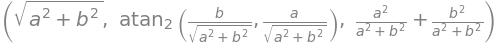

In [199]:
from sympy import init_printing
init_printing()
a, b, c, d = sym.symbols('a b c d', real=True)
scale_rotate_flip_sympy(sym.Matrix([[a,b],[-b, a]]))

In [200]:
scale_rotate_flip_sympy(sym.Matrix([[0,0],[0,0]]))

In [201]:
M = sym.Matrix([[a,b],[c,d]])

In [202]:
M[0,1]

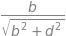

In [203]:
sym.sin(sym.atan2(b,d))

In [204]:
bpos = sym.Symbol('bpos', nonnegative=True)
bneg = sym.Symbol('bneg', nonpositive=True)

In [205]:
def normalize_types(self):
    return self.derive(
        overfocus=float(self.overfocus),
        scan_pixel_pitch=float(self.scan_pixel_pitch),
        scan_center=PixelYX(
            y=float(self.scan_center.y),
            x=float(self.scan_center.x),
        ),
        scan_rotation=float(self.scan_rotation),
        camera_length=float(self.camera_length),
        detector_pixel_pitch=float(self.detector_pixel_pitch),
        detector_center=PixelYX(
            y=float(self.detector_center.y),
            x=float(self.detector_center.x),
        ),
        detector_rotation=float(self.detector_rotation),
        semiconv=float(self.semiconv),
        flip_factor=float(self.flip_factor),
        descan_error=DescanError(
            pxo_pyi=float(self.descan_error.pxo_pyi),
            pyo_pyi=float(self.descan_error.pyo_pyi),
            pxo_pxi=float(self.descan_error.pxo_pxi),
            pyo_pxi=float(self.descan_error.pyo_pxi),
            sxo_pyi=float(self.descan_error.sxo_pyi),
            syo_pyi=float(self.descan_error.syo_pyi),
            sxo_pxi=float(self.descan_error.sxo_pxi),
            syo_pxi=float(self.descan_error.syo_pxi),
            offpxi=float(self.descan_error.offpxi),
            offpyi=float(self.descan_error.offpyi),
            offsxi=float(self.descan_error.offsxi),
            offsyi=float(self.descan_error.offsyi),
        ),
    )

In [206]:
def derive(
    params: Parameters4DSTEM,
    overfocus: sym.Basic | None = None,  # m
    scan_pixel_pitch: sym.Basic | None = None,  # m
    scan_center: PixelYX | None = None,
    scan_rotation: sym.Basic | None = None,  # rad
    camera_length: sym.Basic | None = None,  # m
    detector_pixel_pitch: sym.Basic | None = None,  # m
    detector_center: PixelYX | None = None,
    detector_rotation: sym.Basic | None = None,  # rad
    semiconv: sym.Basic | None = None,  # rad
    flip_y: sym.logic.boolalg.Boolean | None = None,
    flip_factor: sym.Basic | None = None,
    descan_error: DescanError | None = None,
) -> "Parameters4DSTEM":
    if flip_factor is not None:
        assert flip_y is None
    if flip_y is not None:
        flip_factor = -1. if flip_y else 1.
            
    self = params
    
    return Parameters4DSTEM(
        overfocus=overfocus if overfocus is not None else self.overfocus,
        scan_pixel_pitch=(
            scan_pixel_pitch
            if scan_pixel_pitch is not None
            else self.scan_pixel_pitch
        ),
        scan_center=scan_center if scan_center is not None else self.scan_center,
        scan_rotation=scan_rotation
        if scan_rotation is not None
        else self.scan_rotation,
        camera_length=camera_length
        if camera_length is not None
        else self.camera_length,
        detector_pixel_pitch=(
            detector_pixel_pitch
            if detector_pixel_pitch is not None
            else self.detector_pixel_pitch
        ),
        detector_center=(
            detector_center if detector_center is not None else self.detector_center
        ),
        detector_rotation=(
            detector_rotation
            if detector_rotation is not None
            else self.detector_rotation
        ),
        semiconv=semiconv if semiconv is not None else self.semiconv,
        flip_factor=flip_factor if flip_factor is not None else self.flip_factor,
        descan_error=descan_error
        if descan_error is not None
        else self.descan_error,
    )

In [207]:
def adjust_scan_rotation(self, scan_rotation) -> "Parameters4DSTEM":
    de = self.descan_error
    angle = scan_rotation - self.scan_rotation

    # Rotate the input direction
    pxo_pyi, pxo_pxi = rotate(angle).multiply(sym.Matrix([de.pxo_pyi, de.pxo_pxi]))  # add simplificatoin? dotprodsimp=True
    pyo_pyi, pyo_pxi = rotate(angle).multiply(sym.Matrix([de.pyo_pyi, de.pyo_pxi]))
    sxo_pyi, sxo_pxi = rotate(angle).multiply(sym.Matrix([de.sxo_pyi, de.sxo_pxi]))
    syo_pyi, syo_pxi = rotate(angle).multiply(sym.Matrix([de.syo_pyi, de.syo_pxi]))
    new_de = DescanError(
        pxo_pyi=pxo_pyi,
        pyo_pyi=pyo_pyi,
        pxo_pxi=pxo_pxi,
        pyo_pxi=pyo_pxi,
        sxo_pyi=sxo_pyi,
        syo_pyi=syo_pyi,
        sxo_pxi=sxo_pxi,
        syo_pxi=syo_pxi,
        offpxi=de.offpxi,
        offpyi=de.offpyi,
        offsxi=de.offsxi,
        offsyi=de.offsyi,
    )
    return self.derive(
        scan_rotation=scan_rotation,
        descan_error=new_de,
    )

In [208]:
de = p.descan_error
de.pxo_pyi
def sums(mo, no):
    return mo+no
sums(1,2)
def d(ex: sym.Basic | None=None):
    return ex if ex is not None else 'error'
d(a)

AttributeError: 'Symbol' object has no attribute 'descan_error'

In [209]:
def rotate(radians):
    return sym.rot_givens(0, 1, radians, dim=2)

In [210]:
A= rotate(sym.pi)
A

⎡-1  0 ⎤
⎢      ⎥
⎣0   -1⎦

In [211]:
A.multiply(sym.Matrix([1,1]))

⎡-1⎤
⎢  ⎥
⎣-1⎦

In [212]:
x = sym.Symbol('x')

In [213]:
x is not None

True

In [214]:
def d(ex: sym.Basic | None=None):
    return ex if ex is not None else 'error'

In [215]:
isinstance(x, sym.Basic)

True

In [216]:
isinstance(sym.logic.boolalg.BooleanTrue(), sym.logic.boolalg.Boolean)

True

In [217]:
parms= Parameters4DSTEM(
    overfocus=0.01*a,
    scan_pixel_pitch=1e-6*b,
    scan_center=PixelYX(0.1*c, 0.2*d),
    scan_rotation=0.01*e,
    camera_length=1.0*f,
    detector_pixel_pitch=50e-6*g,
    detector_center=PixelYX(0.1*h, 0.1*i),
    semiconv=1e-3*j,  # radian
    flip_factor=1.0*k,
    descan_error=DescanError(pxo_pxi=l, pxo_pyi=m, pyo_pxi=n, pyo_pyi=o, sxo_pxi=p, sxo_pyi=q, syo_pxi=r, syo_pyi=s, offpxi=t, offpyi=u, offsxi=v, offsyi=w),
)
parms

TypeError: unsupported operand type(s) for *: 'float' and 'function'

In [218]:
from sympy.abc import a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x
derive(params=parms, overfocus=a,
    scan_pixel_pitch=b,
    scan_center=PixelYX(y=c, x=d),
    scan_rotation=None,
    camera_length=f,
    detector_pixel_pitch=g,
    detector_center=PixelYX(y=h, x=i),
    detector_rotation=j,
    semiconv=k,
    flip_y=S.true,
    flip_factor=None,
    descan_error=DescanError(pxo_pxi=l, pxo_pyi=m, pyo_pxi=n, pyo_pyi=o, sxo_pxi=p, sxo_pyi=q, syo_pxi=r, syo_pyi=s, offpxi=t, offpyi=u, offsxi=v, offsyi=w))

NameError: name 'parms' is not defined

In [219]:
def adjust_scan_pixel_pitch(params, scan_pixel_pitch: sym.Basic) -> "Parameters4DSTEM":
    self = params
    
    de = self.descan_error
    ratio = self.scan_pixel_pitch / scan_pixel_pitch

    new_de = DescanError(
        pxo_pyi=de.pxo_pyi * ratio,
        pyo_pyi=de.pyo_pyi * ratio,
        pxo_pxi=de.pxo_pxi * ratio,
        pyo_pxi=de.pyo_pxi * ratio,
        sxo_pyi=de.sxo_pyi * ratio,
        syo_pyi=de.syo_pyi * ratio,
        sxo_pxi=de.sxo_pxi * ratio,
        syo_pxi=de.syo_pxi * ratio,
        offpxi=de.offpxi,
        offpyi=de.offpyi,
        offsxi=de.offsxi,
        offsyi=de.offsyi,
    )
    return self.derive(
        scan_pixel_pitch=scan_pixel_pitch,
        descan_error=new_de,
    )

In [220]:
adjust_scan_rotation(parms, x)

NameError: name 'parms' is not defined

In [221]:
adjust_scan_pixel_pitch(parms, x)

NameError: name 'parms' is not defined

In [222]:
rotate(x)

⎡cos(x)   sin(x)⎤
⎢               ⎥
⎣-sin(x)  cos(x)⎦

In [223]:
    def build(
        cls,
        params: Parameters4DSTEM,
        scan_pos: PixelYX,
        specimen: Optional[Component] = None,
    ) -> "Model4DSTEM":
        scan_to_real = rotate(params.scan_rotation) @ scale(params.scan_pixel_pitch)
        real_to_scan = scale(1 / params.scan_pixel_pitch) @ rotate(
            -params.scan_rotation)
        scan_y, scan_x = scan_to_real @ sym.Matrix(
            [
                scan_pos.y - params.scan_center.y,
                scan_pos.x - params.scan_center.x,
            ]
        )
        detector_to_real = (
            scale(params.detector_pixel_pitch)
            @ rotate(params.detector_rotation)
            @ flip_y(flip_factor=params.flip_factor)
        )
        real_to_detector = (
            flip_y(flip_factor=1 / params.flip_factor)
            @ rotate(-params.detector_rotation)
            @ scale(1 / params.detector_pixel_pitch)
        )
        if specimen is None:
            specimen = Plane(z=params.overfocus)
        else:
            try:
                # FIXME better solution later?
                assert params.xp.allclose(specimen.z, params.overfocus)
            except TracerBoolConversionError:
                pass
        return cls(
            source=PointSource(z=0, semi_conv=params.semiconv),
            _scan_to_real=scan_to_real,
            _real_to_scan=real_to_scan,
            _detector_to_real=detector_to_real,
            _real_to_detector=real_to_detector,
            scanner=Scanner(z=params.overfocus, scan_pos_x=scan_x, scan_pos_y=scan_y),
            specimen=specimen,
            descanner=Descanner(
                z=params.overfocus,
                scan_pos_x=scan_x,
                scan_pos_y=scan_y,
                descan_error=params.descan_error,
            ),
            detector=Plane(z=params.overfocus + params.camera_length),
            scan_center=params.scan_center,
            detector_center=params.detector_center,
            xp=params.xp,
        )

In [224]:
number = 5
b = sym.symbols(f"b_0:{number}")
b_dict = {f"b_{i}": b[i] for i in range(number)}

In [225]:
b

In [226]:
b_dict

{'b_0': b_0, 'b_1': b_1, 'b_2': b_2, 'b_3': b_3, 'b_4': b_4}

In [227]:
symbols = [sym.symbols(f"{attr}") for attr in par.__dict__.keys()]

In [228]:
symbols

In [229]:
de=DescanError()
de._asdict().keys()

dict_keys(['pxo_pxi', 'pxo_pyi', 'pyo_pxi', 'pyo_pyi', 'sxo_pxi', 'sxo_pyi', 'syo_pxi', 'syo_pyi', 'offpxi', 'offpyi', 'offsxi', 'offsyi'])

In [230]:
symbols_dict = {attr: sym.symbols(f"{attr}") for attr in par.__dict__.keys()}

In [231]:
def symbol_maker(params_cls, postfix):
    if postfix is not None:
        symbols_dict = {attr: sym.symbols(f"{attr}_{postfix}") for attr in params_cls.__match_args__}
    else:
        symbols_dict = {attr: sym.symbols(f"{attr}") for attr in params_cls.__match_args__}
    return params_cls(**symbols_dict)

In [232]:
symbol_maker(Parameters4DSTEM, 'new')

Parameters4DSTEM(overfocus=overfocus_new, scan_pixel_pitch=scan_pixel_pitch_new, scan_center=scan_center_new, scan_rotation=scan_rotation_new, camera_length=camera_length_new, detector_pixel_pitch=detector_pixel_pitch_new, detector_center=detector_center_new, semiconv=semiconv_new, flip_factor=flip_factor_new, descan_error=descan_error_new, detector_rotation=detector_rotation_new, xp=xp_new)

In [233]:
DescanError.__annotations__['pxo_pxi'] is float

True

In [234]:
def symbol_maker(params_cls, postfix, recurse_for=tuple()):
    symbols_dict = {}
    for attr in params_cls.__annotations__.keys():
        cls = params_cls.__annotations__[attr]
        if cls in recurse_for:
            symbols_dict[attr] = symbol_maker(cls, postfix, recurse_for)
        else:
            symbols_dict[attr] = sym.symbols(f"{attr}_{postfix}")
    return params_cls(**symbols_dict)

In [235]:
p = symbol_maker(Parameters4DSTEM, 'new', recurse_for=[DescanError, PixelYX])

In [236]:
pxo_pxi_new

NameError: name 'pxo_pxi_new' is not defined

In [237]:
Parameters4DSTEM.__annotations__['descan_error'].__annotations__.keys()

dict_keys(['pxo_pxi', 'pxo_pyi', 'pyo_pxi', 'pyo_pyi', 'sxo_pxi', 'sxo_pyi', 'syo_pxi', 'syo_pyi', 'offpxi', 'offpyi', 'offsxi', 'offsyi'])

In [238]:
PixelYX.__annotations__['y']

typing.Union[int, float]

In [239]:
PixelYX.__name__

'PixelYX'

In [240]:
def _mk_adjust_scan_pixel_pitch(cls=Model4DSTEM):
        """
        This function first finds a general symbolic expression for each component of the
        new descan error given old parameteres as symbols, then converts the sympy
        expressions for each component into a function that allows fast numeric evaluation.
        After that the new model is constructed.
        """
        def symbol_maker(params_cls, postfix, postfix_vars=tuple(), recurse_for=tuple()):
            symbols_dict = {}
            for attr in params_cls.__annotations__.keys():
                cls = params_cls.__annotations__[attr]
                if cls in recurse_for:
                    symbols_dict[attr] = symbol_maker(cls, postfix, postfix_vars, recurse_for)
                else:
                    if attr in postfix_vars:
                        symbols_dict[attr] = sym.symbols(f"{attr}_{postfix}")
                    else:
                        symbols_dict[attr] = sym.symbols(f"{attr}")
            return params_cls(**symbols_dict)

        params_old = symbol_maker(Parameters4DSTEM, 'old', postfix_vars=['scan_pixel_pitch', *(DescanError.__match_args__)], recurse_for=[DescanError, PixelYX])
        params_new = symbol_maker(Parameters4DSTEM, 'new', postfix_vars=['scan_pixel_pitch', *(DescanError.__match_args__)], recurse_for=[DescanError, PixelYX])

        # Use trace() to calculate detector_px() for the old and for the new parameters.
        # Then set the results equal to each other and solve the equation with respect
        # to the new descan error. For this purpose construct two expressions - for y and x
        # coordiates respectively - and apply sympy.solve().
        # Note that the equations should hold for every value of the scan position (in particular,
        # scan_pos_y scan_pos_x), and also for every value of the camera length. To implement that,
        # expand the expressions, then rearange them to be polynomials in the variables scan_pos_y,
        # scan_pos_x and camera_length, which automatically means collecting the coefficients
        # of each variable through the usage of sympy.Poly(). Finally, set the collected
        # coefficients of the polynomials to zero, which mathematically implies the desired
        # property: a polynomial is zero for all the values of its variables if and only if
        # all its coefficients equal to zero.
        # In such a way one receives equations for each of the collected coefficients, which
        # suffices to make the system solvable for all the 12 components of descan error as
        # variables.

        # The received expressions for each component of the new DescanError fully coincide
        # with the ones calculated by hand earlier.
        def detector_px(m: Model4DSTEM):
            ray = m.make_source_ray(
                source_dy=0.,
                source_dx=0.,
            ).ray
            data = m.trace(ray)
            return data['detector'].sampling['detector_px']

        scan_pos_y, scan_pos_x = sym.symbols('scan_pos_y scan_pos_x')
        scan_pos = PixelYX(scan_pos_y, scan_pos_x)

        model_old = cls.build(params=params_old, scan_pos=scan_pos)
        model_new = cls.build(params=params_new, scan_pos=scan_pos)

        det_px_old = detector_px(model_old)
        det_px_new = detector_px(model_new)

        expanded_expr_y = sym.expand(det_px_old.y - det_px_new.y)
        expanded_expr_x = sym.expand(det_px_old.x - det_px_new.x)

        collected_y = sym.Poly(expanded_expr_y, scan_pos_y, scan_pos_x, params_old.camera_length)
        collected_x = sym.Poly(expanded_expr_x, scan_pos_y, scan_pos_x, params_old.camera_length)

        coeff = collected_y.coeffs() + collected_x.coeffs()

        solution = sym.solve([eq for eq in coeff], [params_new.descan_error.pxo_pxi,
                                                    params_new.descan_error.pxo_pyi,
                                                    params_new.descan_error.pyo_pxi,
                                                    params_new.descan_error.pyo_pyi,
                                                    params_new.descan_error.sxo_pxi,
                                                    params_new.descan_error.sxo_pyi,
                                                    params_new.descan_error.syo_pxi,
                                                    params_new.descan_error.syo_pyi,
                                                    params_new.descan_error.offpxi,
                                                    params_new.descan_error.offpyi,
                                                    params_new.descan_error.offsxi,
                                                    params_new.descan_error.offsyi],
                            simplify=True)
        # apply_function() constructs a function using sympy.lambdify() that allows inserting
        # real values to each expression of the general solution and after that evaluating them
        # numerically. The lambdify() method can be supplemented with the specific
        # numerical backend by inserting e.g. "numpy", "cupy" or "jax" to the optional
        # argument "modules=" of sympy.lambdify().
        def apply_function(m: Model4DSTEM, scan_pixel_pitch) -> Model4DSTEM:
            substituted = sym.lambdify(
                [
                    params_old.descan_error.pxo_pxi, params_old.descan_error.pxo_pyi,
                    params_old.descan_error.pyo_pxi, params_old.descan_error.pyo_pyi,
                    params_old.descan_error.sxo_pxi, params_old.descan_error.sxo_pyi,
                    params_old.descan_error.syo_pxi, params_old.descan_error.syo_pyi,
                    params_old.descan_error.offpxi, params_old.descan_error.offpyi,
                    params_old.descan_error.offsxi, params_old.descan_error.offsyi,
                    params_old.scan_pixel_pitch, params_new.scan_pixel_pitch
                ], [solution[attr] for attr in [
                    params_new.descan_error.pxo_pxi, params_new.descan_error.pxo_pyi,
                    params_new.descan_error.pyo_pxi, params_new.descan_error.pyo_pyi,
                    params_new.descan_error.sxo_pxi, params_new.descan_error.sxo_pyi,
                    params_new.descan_error.syo_pxi, params_new.descan_error.syo_pyi,
                    params_new.descan_error.offpxi, params_new.descan_error.offpyi,
                    params_new.descan_error.offsxi, params_new.descan_error.offsyi
                ]])
            evaluated = substituted(
                *m.descanner.descan_error,
                m.params.scan_pixel_pitch, scan_pixel_pitch
            )
            new_de = DescanError(*evaluated)
            new_params = m.params.derive(descan_error=new_de)
            new_model = Model4DSTEM.build(new_params, m.scan_pos)
            return new_model

        return apply_function

In [241]:
params = Parameters4DSTEM(
        overfocus=0.7,
        scan_pixel_pitch=0.005,
        scan_center=PixelYX(y=17, x=13),
        scan_rotation=1.234,
        camera_length=2.3,
        detector_pixel_pitch=0.0247,
        detector_center=PixelYX(y=11, x=19),
        detector_rotation=2.134,
        semiconv=0.023,
        flip_factor=-1.,
        descan_error=DescanError(offpxi=.345, pxo_pxi=948)
    )
mod= Model4DSTEM.build(params=params, scan_pos=PixelYX(y=13, x=7))

desc = _mk_adjust_scan_pixel_pitch()(mod, 2.)
desc

Model4DSTEM(source=PointSource(z=0, semi_conv=0.023, offset_xy=CoordsXY(x=0.0, y=0.0)), scanner=Scanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0), specimen=Plane(z=0.7), descanner=Descanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0, descan_error=DescanError(pxo_pxi=2.37000000000000, pxo_pyi=0, pyo_pxi=0, pyo_pyi=0, sxo_pxi=0, sxo_pyi=0, syo_pxi=0, syo_pyi=0, offpxi=0.345, offpyi=0.0, offsxi=0.0, offsyi=0.0)), detector=Plane(z=3.0), _scan_to_real=Matrix([
[ 0.00165232554035865, 0.00471909104687317],
[-0.00471909104687317, 0.00165232554035865]]), _real_to_scan=Matrix([
[ 66.093021614346, -188.763641874927],
[188.763641874927,   66.093021614346]]), _detector_to_real=Matrix([
[-0.0247,      0],
[      0, 0.0247]]), _real_to_detector=Matrix([
[-40.4858299595142,                0],
[                0, 40.4858299595142]]), scan_center=PixelYX(y=17, x=13), detector_cente

In [242]:
def symbol_maker(params_cls, postfix, postfix_vars=tuple(), recurse_for=tuple()):
            symbols_dict = {}
            for attr in params_cls.__annotations__.keys():
                cls = params_cls.__annotations__[attr]
                if cls in recurse_for:
                    symbols_dict[attr] = symbol_maker(cls, postfix, postfix_vars, recurse_for)
                else:
                    if attr in postfix_vars:
                        symbols_dict[attr] = sym.symbols(f"{attr}_{postfix}")
                    else:
                        symbols_dict[attr] = sym.symbols(f"{attr}")
            return params_cls(**symbols_dict)

In [243]:
p = symbol_maker(Parameters4DSTEM, 'new', postfix_vars=['scan_pixel_pitch', *(DescanError.__match_args__)], recurse_for=[DescanError, PixelYX])

In [244]:
p

Parameters4DSTEM(overfocus=overfocus, scan_pixel_pitch=scan_pixel_pitch_new, scan_center=PixelYX(y=y, x=x), scan_rotation=scan_rotation, camera_length=camera_length, detector_pixel_pitch=detector_pixel_pitch, detector_center=PixelYX(y=y, x=x), semiconv=semiconv, flip_factor=flip_factor, descan_error=DescanError(pxo_pxi=pxo_pxi_new, pxo_pyi=pxo_pyi_new, pyo_pxi=pyo_pxi_new, pyo_pyi=pyo_pyi_new, sxo_pxi=sxo_pxi_new, sxo_pyi=sxo_pyi_new, syo_pxi=syo_pxi_new, syo_pyi=syo_pyi_new, offpxi=offpxi_new, offpyi=offpyi_new, offsxi=offsxi_new, offsyi=offsyi_new), detector_rotation=detector_rotation, xp=xp)

In [245]:
params = Parameters4DSTEM(
        overfocus=0.7,
        scan_pixel_pitch=0.005,
        scan_center=PixelYX(y=17, x=13),
        scan_rotation=1.234,
        camera_length=2.3,
        detector_pixel_pitch=0.0247,
        detector_center=PixelYX(y=11, x=19),
        detector_rotation=2.134,
        semiconv=0.023,
        flip_factor=-1.,
        descan_error=DescanError(offpxi=.345, pxo_pxi=948)
    )
mod= Model4DSTEM.build(params=params, scan_pos=PixelYX(y=13, x=7))

desc = mod._mk_adjust_scan_pixel_pitch()(mod, 2.)
desc

Model4DSTEM(source=PointSource(z=0, semi_conv=0.023, offset_xy=CoordsXY(x=0.0, y=0.0)), scanner=Scanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0), specimen=Plane(z=0.7), descanner=Descanner(z=0.7, scan_pos_x=0.00896241094534078, scan_pos_y=-0.0349238484426736, scan_tilt_x=0.0, scan_tilt_y=0.0, descan_error=DescanError(pxo_pxi=2.37000000000000, pxo_pyi=0, pyo_pxi=0, pyo_pyi=0, sxo_pxi=0, sxo_pyi=0, syo_pxi=0, syo_pyi=0, offpxi=0.345, offpyi=0.0, offsxi=0.0, offsyi=0.0)), detector=Plane(z=3.0), _scan_to_real=Matrix([
[ 0.00165232554035865, 0.00471909104687317],
[-0.00471909104687317, 0.00165232554035865]]), _real_to_scan=Matrix([
[ 66.093021614346, -188.763641874927],
[188.763641874927,   66.093021614346]]), _detector_to_real=Matrix([
[-0.0247,      0],
[      0, 0.0247]]), _real_to_detector=Matrix([
[-40.4858299595142,                0],
[                0, 40.4858299595142]]), scan_center=PixelYX(y=17, x=13), detector_cente

In [ ]:
p = symbol_maker(Parameters4DSTEM, 'new', [DescanError, PixelYX])
f = sym.lambdify([*p.descan_error, p.scan_pixel_pitch], p.descan_error.pxo_pxi+1)
f(*(1 for i in range(13)))